# Rollout Visualisation — Video + Joint Angles + Torques + Velocities

Downloads the video and matching CSV from a W&B run, then shows:
1. **Video** of the rollout
2. **Manipulator joint angles** (wrapped to [−π, +π])
3. **Finger / gripper positions** (separate graph)
4. **All velocities** overlaid
5. **All torques** overlaid

In [281]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, json
from IPython.display import Video, display, HTML

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1 — Configuration

In [282]:
# ──────────── EDIT THESE ────────────
ENTITY  = "weissma6-zhaw-school-of-engineering"
PROJECT = "UR10_pick_ppo"


# Leave None to auto-select the most recent finished run
RUN_ID  = "frcR=100_Damp=2_torfric_0.1_DR_off_20260208_154603_938"

# ────────────────────────────────────
'''
frcR=100_Damp=2_torfric_0.1_DR_off_20260208_150415_5529 - works 


Ineresting examples: 
"DomainR_MFR_lr0.0006_512_20260206_161524_7373" - drops the box successfully after pick


"DomainR_MFR_lr0.0012_KPKV400030_20260206_194705_805" - good performance  - Too high forces
"DomainR_off_lr0.0006_KPKV400030_20260206_194816_3438" - good performance


"Step_logging_lr0.0008_512_20260206_083107_3735" - good droping example
DomainR_off_lr0.0006_KPKV400030_20260206_194816_3438 - without domain randomization, good performance, but also drops the box after pick

Panda examples:
Panda_default_seed6 - baseline
"" -

'''

SAVE_DIR = "run_graphs/"
RUN_DIR = os.path.join(SAVE_DIR, RUN_ID)
os.makedirs(RUN_DIR, exist_ok=True)
print(f"Saving to {RUN_DIR}")

Saving to run_graphs/frcR=100_Damp=2_torfric_0.1_DR_off_20260208_154603_938


## 2 — Fetch run & files

In [283]:
api = wandb.Api()

if RUN_ID:
    run = api.run(f'{ENTITY}/{PROJECT}/{RUN_ID}')
else:
    runs = api.runs(f'{ENTITY}/{PROJECT}', filters={'state': 'finished'},
                    order='-created_at', per_page=1)
    run = runs[0]

print(f'Run: {run.name}  ({run.id})')
print(f'State: {run.state}  |  Runtime: {run.summary.get("_runtime", 0)/60:.1f} min')

run_files = list(run.files())
print(f'\nFiles ({len(run_files)}):')
for f in run_files:
    print(f'  {f.name}  ({f.size:,} bytes)')

Run: frcR=100_Damp=2_torfric_0.1_DR_off_20260208_154603_938  (frcR=100_Damp=2_torfric_0.1_DR_off_20260208_154603_938)
State: finished  |  Runtime: 43.0 min

Files (27):
  artifact/2456295893/wandb_manifest.json  (351 bytes)
  artifact/2456345970/wandb_manifest.json  (351 bytes)
  artifact/2456385353/wandb_manifest.json  (351 bytes)
  artifact/2456400145/wandb_manifest.json  (351 bytes)
  artifact/2456400563/wandb_manifest.json  (563 bytes)
  artifact/2456402049/wandb_manifest.json  (0 bytes)
  config.yaml  (4,450 bytes)
  media/table/eval/rollout_data_14745600_399968b1ff8893d55ed4.table.json  (244,994 bytes)
  media/table/eval/rollout_data_21299200_53d7cec541de9fb1cc46.table.json  (244,860 bytes)
  media/table/eval/rollout_data_22937600_7cdd45d0dba97b280503.table.json  (244,291 bytes)
  media/table/eval/rollout_data_6553600_e10539d8a944f3635286.table.json  (245,502 bytes)
  media/videos/eval/video_13107200_5687874ace584c4f42e5.mp4  (986,291 bytes)
  media/videos/eval/video_19660800_082

In [284]:
import re

os.makedirs('dl', exist_ok=True)

def _extract_steps(f):
    m = re.search(r'steps(\d+)', f.name)
    return int(m.group(1)) if m else 0

# Only use the UR10PickCube files (not the media/videos duplicates)
named_videos = [f for f in run_files if f.name.endswith('.mp4') and 'UR10PickCube' in f.name]
named_csvs   = [f for f in run_files if f.name.endswith('.csv') and 'UR10PickCube' in f.name]

# Sort by step count
named_videos.sort(key=_extract_steps)
named_csvs.sort(key=_extract_steps)

print('Available video/csv pairs:')
for v in named_videos:
    steps = _extract_steps(v)
    has_csv = any(_extract_steps(c) == steps for c in named_csvs)
    print(f'  steps={steps:>12,}  csv={"✓" if has_csv else "✗"}  {os.path.basename(v.name)}')

# Pick the highest-step pair
vf = named_videos[-1]
vf_steps = _extract_steps(vf)
cf = [c for c in named_csvs if _extract_steps(c) == vf_steps][0]

# Download and flatten into dl/
vf.download(root='dl', replace=True)
cf.download(root='dl', replace=True)
video_path = os.path.join('dl', vf.name)
csv_path   = os.path.join('dl', cf.name)

print(f'\nSelected video: {os.path.basename(vf.name)}')
print(f'Selected CSV:   {os.path.basename(cf.name)}')
rew_match = re.search(r"rew([\d.]+)", vf.name)
rew_str = rew_match.group(1) if rew_match else "?"
print(f'Steps: {vf_steps:,}  |  Reward: {rew_str}')

df = pd.read_csv(csv_path)
print(f'\nLoaded {len(df)} rows × {len(df.columns)} columns')
display(df.head(3))


Available video/csv pairs:
  steps=   6,553,600  csv=✓  UR10PickCube_frcR=100_Damp=2_torfric_0.1_DR_off_rew877.3_steps6553600.mp4
  steps=  14,745,600  csv=✓  UR10PickCube_frcR=100_Damp=2_torfric_0.1_DR_off_rew1422.4_steps14745600.mp4
  steps=  21,299,200  csv=✓  UR10PickCube_frcR=100_Damp=2_torfric_0.1_DR_off_rew877.5_steps21299200.mp4
  steps=  22,937,600  csv=✓  UR10PickCube_frcR=100_Damp=2_torfric_0.1_DR_off_rew981.8_steps22937600.mp4

Selected video: UR10PickCube_frcR=100_Damp=2_torfric_0.1_DR_off_rew981.8_steps22937600.mp4
Selected CSV:   UR10PickCube_frcR=100_Damp=2_torfric_0.1_DR_off_rew981.8_steps22937600.csv
Steps: 22,937,600  |  Reward: 981.8

Loaded 151 rows × 87 columns


,timestep,reward,ctrl_0,ctrl_1,ctrl_2,ctrl_3,ctrl_4,ctrl_5,ctrl_6,world_x,...,qpos_joint_5,qpos_joint_6,qpos_joint_7,qpos_joint_8,qpos_joint_9,qpos_joint_10,qpos_joint_11,qpos_joint_12,qpos_joint_13,qpos_joint_14
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,-1.546080,0.001145,0.008660,0.550478,0.039383,0.030000,1.0,0.000000e+00,0.000000e+00,0.000000e+00
1,1,0.879101,-0.922566,0.972916,0.703616,-0.810213,-0.696037,-0.257803,-0.328780,0.0,...,-1.547945,0.002222,0.003510,0.550478,0.039383,0.029986,1.0,-7.164016e-10,-4.477507e-11,-3.274181e-10
2,2,0.925251,-0.985904,0.975888,0.994658,-0.959011,-0.687905,-0.623295,-0.381233,0.0,...,-1.553719,0.001528,0.001158,0.550478,0.039383,0.029993,1.0,-1.119396e-10,-8.283405e-10,-7.348717e-09


## 3 — Detect data channels

In [285]:
cols = list(df.columns)


def _num_sort_key(col):
    """Sort by trailing number so joint_2 comes before joint_10."""
    m = re.search(r'(\d+)$', col)
    return (0, int(m.group(1))) if m else (1, col)

qpos_cols   = sorted([c for c in cols if c.startswith('qpos_')],   key=_num_sort_key)
vel_cols    = sorted([c for c in cols if c.startswith('vel_')],     key=_num_sort_key)
torque_cols = sorted([c for c in cols if c.startswith('torque_')],  key=_num_sort_key)
ctrl_cols   = sorted([c for c in cols if c.startswith('ctrl_')],    key=_num_sort_key)

print(f'qpos   columns ({len(qpos_cols)}): {qpos_cols}')
print(f'vel    columns ({len(vel_cols)}): {vel_cols}')
print(f'torque columns ({len(torque_cols)}): {torque_cols}')
print(f'ctrl   columns ({len(ctrl_cols)}): {ctrl_cols}')

# Quick sanity check: qpos_joint_8 should be box_x ≈ 0.7
print(f'\nSanity: qpos_cols[8] = {qpos_cols[8]}, first value = {df[qpos_cols[8]].iloc[0]:.4f}  (expect ~0.7)')

# Build readable name lookups
qpos_names   = [c.replace('qpos_', '')   for c in qpos_cols]
vel_names    = [c.replace('vel_', '')     for c in vel_cols]
torque_names = [c.replace('torque_', '')  for c in torque_cols]
ctrl_names   = [c.replace('ctrl_', '')    for c in ctrl_cols]


qpos   columns (15): ['qpos_joint_0', 'qpos_joint_1', 'qpos_joint_2', 'qpos_joint_3', 'qpos_joint_4', 'qpos_joint_5', 'qpos_joint_6', 'qpos_joint_7', 'qpos_joint_8', 'qpos_joint_9', 'qpos_joint_10', 'qpos_joint_11', 'qpos_joint_12', 'qpos_joint_13', 'qpos_joint_14']
vel    columns (14): ['vel_0', 'vel_1', 'vel_2', 'vel_3', 'vel_4', 'vel_5', 'vel_6', 'vel_7', 'vel_8', 'vel_9', 'vel_10', 'vel_11', 'vel_12', 'vel_13']
torque columns (7): ['torque_wrist_1', 'torque_wrist_2', 'torque_wrist_3', 'torque_elbow', 'torque_hande_fingers_actuator', 'torque_shoulder_lift', 'torque_shoulder_pan']
ctrl   columns (7): ['ctrl_0', 'ctrl_1', 'ctrl_2', 'ctrl_3', 'ctrl_4', 'ctrl_5', 'ctrl_6']

Sanity: qpos_cols[8] = qpos_joint_8, first value = 0.5505  (expect ~0.7)


## 4 — Classify qpos: arm / fingers / box

UR10 qpos layout from XML keyframe:  
`qpos = [arm×6] [finger×2] [box_xyz×3] [box_quat×4]`  
`ctrl  = [arm×6] [gripper×1]`

In [286]:
# ══════════════════════════════════════════════
# UR10 QPOS LAYOUT  (from XML keyframe)
# qpos = [arm×6] [finger×2] [box_xyz×3] [box_quat×4]  = 15 total
# ctrl  = [arm×6] [gripper×1]                          =  7 total
# ══════════════════════════════════════════════
N_ARM    = 6
N_FINGER = 2
N_BOX_XYZ  = 3
N_BOX_QUAT = 4

# ── Readable names for each qpos index ──
QPOS_NAMES = [
    # Arm (0-5)
    'shoulder_pan', 'shoulder_lift', 'elbow',
    'wrist_1', 'wrist_2', 'wrist_3',
    # Fingers (6-7)
    'finger_left', 'finger_right',
    # Box (8-14)
    'box_x', 'box_y', 'box_z',
    'box_qw', 'box_qx', 'box_qy', 'box_qz',
]

# Map generic qpos_joint_N → readable name
qpos_name_map = {}
for i, col in enumerate(qpos_cols):
    qpos_name_map[col] = QPOS_NAMES[i] if i < len(QPOS_NAMES) else col

# Split columns
arm_qpos_cols    = qpos_cols[:N_ARM]
finger_qpos_cols = qpos_cols[N_ARM : N_ARM + N_FINGER]
box_pos_cols     = qpos_cols[N_ARM + N_FINGER : N_ARM + N_FINGER + N_BOX_XYZ]
box_quat_cols    = qpos_cols[N_ARM + N_FINGER + N_BOX_XYZ :]

print(f'Arm joints    ({len(arm_qpos_cols)}):  {[qpos_name_map[c] for c in arm_qpos_cols]}')
print(f'Finger joints ({len(finger_qpos_cols)}):  {[qpos_name_map[c] for c in finger_qpos_cols]}')
print(f'Box position  ({len(box_pos_cols)}):  {[qpos_name_map[c] for c in box_pos_cols]}')
print(f'Box quaternion({len(box_quat_cols)}):  {[qpos_name_map[c] for c in box_quat_cols]}')

# Also map velocity names
VEL_NAMES = [
    'shoulder_pan', 'shoulder_lift', 'elbow',
    'wrist_1', 'wrist_2', 'wrist_3',
    'finger_left', 'finger_right',
    'box_vx', 'box_vy', 'box_vz',
    'box_wx', 'box_wy', 'box_wz',
]
vel_name_map = {}
for i, col in enumerate(vel_cols):
    vel_name_map[col] = VEL_NAMES[i] if i < len(VEL_NAMES) else col





Arm joints    (6):  ['shoulder_pan', 'shoulder_lift', 'elbow', 'wrist_1', 'wrist_2', 'wrist_3']
Finger joints (2):  ['finger_left', 'finger_right']
Box position  (3):  ['box_x', 'box_y', 'box_z']
Box quaternion(4):  ['box_qw', 'box_qx', 'box_qy', 'box_qz']


In [287]:
# Verify mapping with initial values
print('\n── Verification (timestep 0) ──')
for col in qpos_cols:
    print(f'  {col:20s} → {qpos_name_map[col]:16s}  = {df[col].iloc[0]:.4f}')

# Finger torque
finger_torque = [c for c in torque_cols if 'finger' in c or 'hand' in c]
print(f'\nFinger torque column: {finger_torque}')
if finger_torque:
    for ft in finger_torque:
        print(f'  {ft}  mean={df[ft].mean():.3f}  range=[{df[ft].min():.3f}, {df[ft].max():.3f}]')


── Verification (timestep 0) ──
  qpos_joint_0         → shoulder_pan      = 0.0206
  qpos_joint_1         → shoulder_lift     = -1.7267
  qpos_joint_2         → elbow             = 2.2040
  qpos_joint_3         → wrist_1           = -2.1525
  qpos_joint_4         → wrist_2           = -1.4809
  qpos_joint_5         → wrist_3           = -1.5461
  qpos_joint_6         → finger_left       = 0.0011
  qpos_joint_7         → finger_right      = 0.0087
  qpos_joint_8         → box_x             = 0.5505
  qpos_joint_9         → box_y             = 0.0394
  qpos_joint_10        → box_z             = 0.0300
  qpos_joint_11        → box_qw            = 1.0000
  qpos_joint_12        → box_qx            = 0.0000
  qpos_joint_13        → box_qy            = 0.0000
  qpos_joint_14        → box_qz            = 0.0000

Finger torque column: ['torque_hande_fingers_actuator']
  torque_hande_fingers_actuator  mean=15.279  range=[-10.502, 32.406]


## 5 — Video + 3D Box Path (side by side)

Box: (0.550,0.039,0.030) → (0.413,0.304,0.020)  Δ=0.2984m



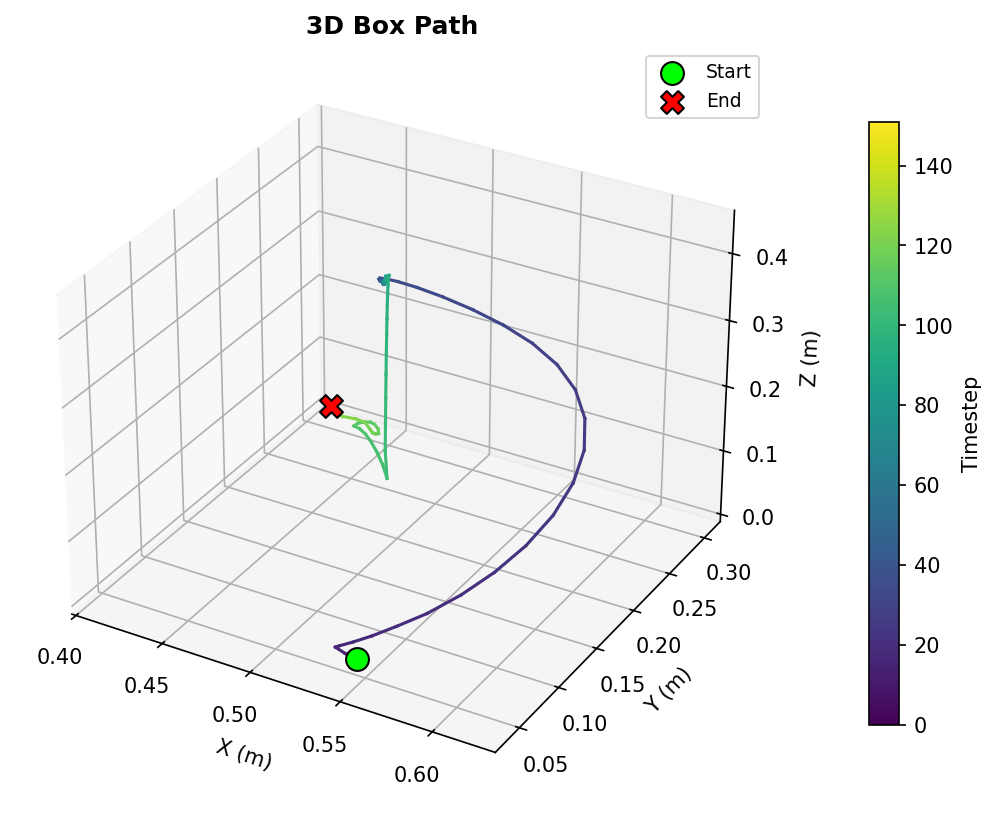

Saved: run_graphs/frcR=100_Damp=2_torfric_0.1_DR_off_20260208_154603_938/frcR=100_Damp=2_torfric_0.1_DR_off_20260208_154603_938_steps22937600.mp4
Saved: run_graphs/frcR=100_Damp=2_torfric_0.1_DR_off_20260208_154603_938/frcR=100_Damp=2_torfric_0.1_DR_off_20260208_154603_938_3d_path.png


In [288]:
import base64
import shutil

# ── Paths ──
path_3d    = os.path.join(RUN_DIR, f'{RUN_ID}_3d_path.png')
path_video = os.path.join(RUN_DIR, f'{RUN_ID}_steps{vf_steps}.mp4')

# ── Generate 3D box path image ──
has_3d = False
if box_pos_cols and len(box_pos_cols) >= 3:
    bx, by, bz = box_pos_cols[0], box_pos_cols[1], box_pos_cols[2]
    x, y, z = df[bx].values, df[by].values, df[bz].values

    fig = plt.figure(figsize=(7, 7))
    ax3 = fig.add_subplot(111, projection='3d')

    t_norm = np.linspace(0, 1, len(x))
    for i in range(len(x) - 1):
        ax3.plot(x[i:i+2], y[i:i+2], z[i:i+2],
                 color=plt.cm.viridis(t_norm[i]), lw=1.5)

    ax3.scatter(x[0], y[0], z[0], s=120, c='lime', marker='o',
                edgecolors='k', zorder=5, label='Start')
    ax3.scatter(x[-1], y[-1], z[-1], s=120, c='red', marker='X',
                edgecolors='k', zorder=5, label='End')

    ax3.set_xlabel('X (m)'); ax3.set_ylabel('Y (m)'); ax3.set_zlabel('Z (m)')
    ax3.set_title('3D Box Path', fontweight='bold')
    ax3.legend(fontsize=9)

    sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(0, len(x)))
    sm.set_array([])
    fig.colorbar(sm, ax=ax3, shrink=0.6, pad=0.1).set_label('Timestep')

    plt.tight_layout()
    plt.savefig(path_3d, dpi=150, bbox_inches='tight')
    plt.close()
    has_3d = True

    dx, dy, dz = x[-1]-x[0], y[-1]-y[0], z[-1]-z[0]
    dist = np.sqrt(dx**2 + dy**2 + dz**2)
    print(f'Box: ({x[0]:.3f},{y[0]:.3f},{z[0]:.3f}) → ({x[-1]:.3f},{y[-1]:.3f},{z[-1]:.3f})  Δ={dist:.4f}m')

# ── Save video ──
shutil.copy(video_path, path_video)

# ── Display side by side ──
with open(path_video, 'rb') as f:
    vid_b64 = base64.b64encode(f.read()).decode('utf-8')

if has_3d:
    with open(path_3d, 'rb') as f:
        img_b64 = base64.b64encode(f.read()).decode('utf-8')

    html = f'''
    <div style="display:flex; gap:20px; align-items:flex-start;">
        <div style="flex:1;">
            <h3>Rollout Video (steps {vf_steps:,})</h3>
            <video width="100%" controls autoplay loop muted>
                <source src="data:video/mp4;base64,{vid_b64}" type="video/mp4">
            </video>
        </div>
        <div style="flex:1;">
            <h3>3D Box Movement Path</h3>
            <img src="data:image/png;base64,{img_b64}" width="100%" />
        </div>
    </div>'''
    display(HTML(html))
else:
    display(HTML(f'''
    <video width="700" controls autoplay loop muted>
        <source src="data:video/mp4;base64,{vid_b64}" type="video/mp4">
    </video>'''))

print(f'Saved: {path_video}')
if has_3d:
    print(f'Saved: {path_3d}')

## 7 — Finger / Gripper Positions

So 4 N·m with a ~40–50mm finger gives roughly 80–100 N per finger, which is about 8–10 kg of grip force per finger. That's comfortably enough to hold a small cube.
You can check the exact lever arm in your MuJoCo XML — look for the finger joint's body position offset or the site where contact happens relative to the joint axis. Something like:

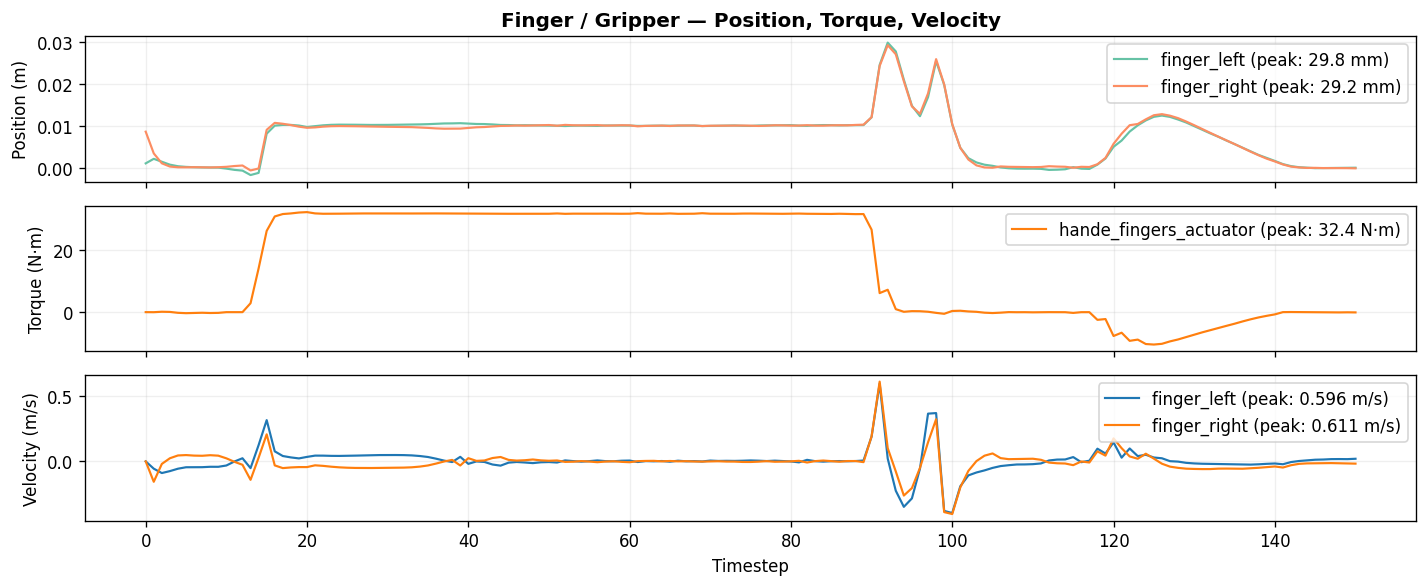

In [289]:
if finger_qpos_cols:
    t = df['timestep'].values
    TOTAL_HEIGHT = 5

    hand_keywords = ["hande", "finger", "gripper", "hand"]
    finger_torque = [c for c in torque_cols
                     if any(kw in torque_name_map.get(c, c).lower() for kw in hand_keywords)]
    finger_vel = [c for c in vel_cols
                  if any(kw in vel_name_map.get(c, c).lower() for kw in hand_keywords)]

    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, figsize=(12, TOTAL_HEIGHT), sharex=True,
        gridspec_kw={'height_ratios': [1, 1, 1]},
    )

    # ── Top: finger positions ──
    colors_pos = plt.cm.Set2.colors
    for i, col in enumerate(finger_qpos_cols):
        peak = df[col].abs().max() * 1000  # convert m → mm
        ax1.plot(t, df[col].values, lw=1.3, color=colors_pos[i % len(colors_pos)],
                 label=f"{qpos_name_map.get(col, col)} (peak: {peak:.1f} mm)")
    ax1.set_ylabel('Position (m)')
    ax1.set_title(f'Finger / Gripper — Position, Torque, Velocity', fontweight='bold')
    ax1.legend(loc='upper right', fontsize=10)
    ax1.grid(True, alpha=0.2)

    # ── Middle: finger torque ──
    if finger_torque:
        for i, col in enumerate(finger_torque):
            peak = df[col].abs().max()
            ax2.plot(t, df[col].values, lw=1.3, color='tab:orange',
                     label=f"{torque_name_map.get(col, col)} (peak: {peak:.1f} N·m)")
        ax2.legend(loc='upper right', fontsize=10)
    else:
        ax2.text(0.5, 0.5, 'No finger torque found',
                 ha='center', va='center', transform=ax2.transAxes, color='gray')
    ax2.set_ylabel('Torque (N·m)')
    ax2.grid(True, alpha=0.2)

    # ── Bottom: finger velocities ──
    if finger_vel:
        colors_vel = plt.cm.tab10.colors
        for i, col in enumerate(finger_vel):
            peak = df[col].abs().max()
            ax3.plot(t, df[col].values, lw=1.3, color=colors_vel[i % len(colors_vel)],
                     label=f"{vel_name_map.get(col, col)} (peak: {peak:.3f} m/s)")
        ax3.legend(loc='upper right', fontsize=10)
    else:
        ax3.text(0.5, 0.5, 'No finger velocity found',
                 ha='center', va='center', transform=ax3.transAxes, color='gray')
    ax3.set_ylabel('Velocity (m/s)')
    ax3.set_xlabel('Timestep')
    ax3.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'finger_pos_torque_vel.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No finger qpos columns found.')

In [290]:
# Finger symmetry check
diff = df[finger_qpos_cols[0]].values - df[finger_qpos_cols[1]].values
print(f'Max finger asymmetry: {np.abs(diff).max():.4f}')
print(f'Final asymmetry:      {np.abs(diff[-1]):.6f}')
print(f'Converged after step: {np.argmax(np.abs(diff) < 0.001)}')

Max finger asymmetry: 0.0075
Final asymmetry:      0.000142
Converged after step: 2


## 7 — UR10 Arm pOsition, torque, Velociy

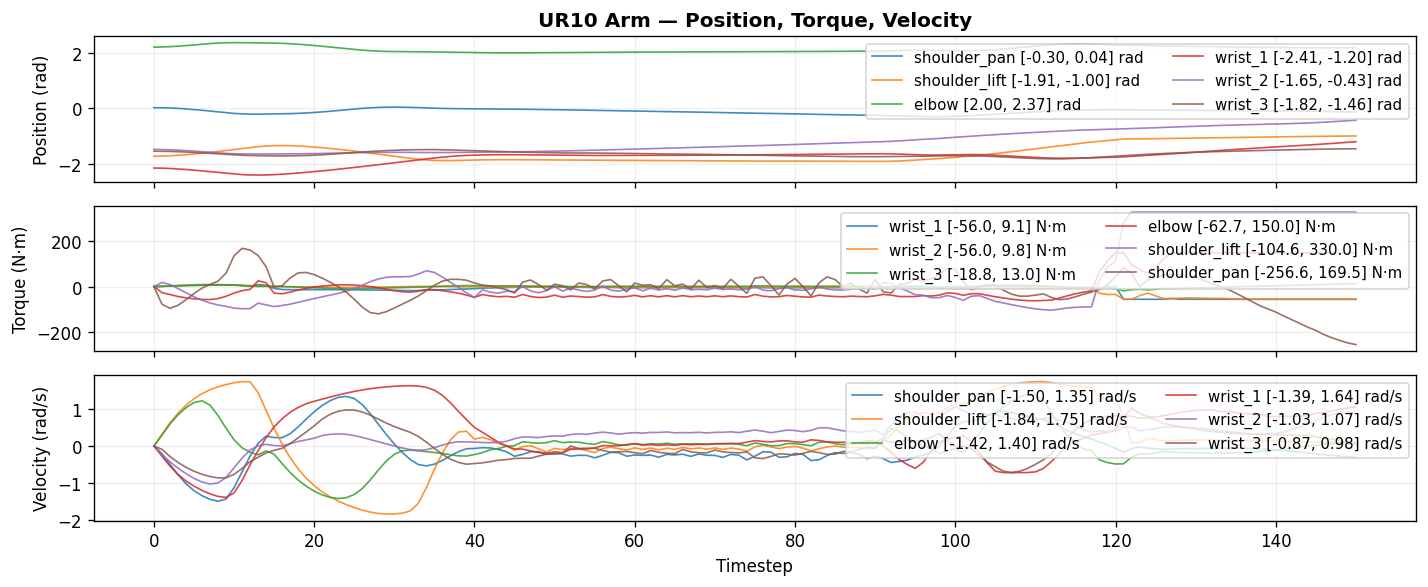

In [291]:
if torque_cols:
    t = df['timestep'].values
    TOTAL_HEIGHT = 5

    hand_keywords = ["hande", "finger", "gripper", "hand"]
    box_keywords = ["box", "free"]
    exclude = hand_keywords + box_keywords

    arm_qpos_cols = [c for c in qpos_cols
                     if not any(kw in qpos_name_map.get(c, c).lower() for kw in exclude)]
    arm_t_cols = [c for c in torque_cols
                  if not any(kw in torque_name_map.get(c, c).lower() for kw in hand_keywords)]
    arm_v_cols = [c for c in vel_cols
                  if not any(kw in vel_name_map.get(c, c).lower() for kw in exclude)]

    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, figsize=(12, TOTAL_HEIGHT), sharex=True,
        gridspec_kw={'height_ratios': [1, 1, 1]},
    )

    colors = plt.cm.tab10.colors

    # ── Top: arm joint positions ──
    for i, col in enumerate(arm_qpos_cols):
        vmin, vmax = df[col].min(), df[col].max()
        ax1.plot(t, df[col].values, lw=1.0, color=colors[i % len(colors)],
                 label=f"{qpos_name_map.get(col, col)} [{vmin:.2f}, {vmax:.2f}] rad", alpha=0.85)
    ax1.set_ylabel('Position (rad)')
    ax1.set_title(f'UR10 Arm — Position, Torque, Velocity', fontweight='bold')
    ax1.legend(loc='upper right', fontsize=9, ncol=2)
    ax1.grid(True, alpha=0.2)

    # ── Middle: arm torques ──
    for i, col in enumerate(arm_t_cols):
        vmin, vmax = df[col].min(), df[col].max()
        ax2.plot(t, df[col].values, lw=1.0, color=colors[i % len(colors)],
                 label=f"{torque_name_map.get(col, col)} [{vmin:.1f}, {vmax:.1f}] N·m", alpha=0.85)
    ax2.set_ylabel('Torque (N·m)')
    ax2.legend(loc='upper right', fontsize=9, ncol=2)
    ax2.grid(True, alpha=0.2)

    # ── Bottom: arm velocities ──
    for i, col in enumerate(arm_v_cols):
        vmin, vmax = df[col].min(), df[col].max()
        ax3.plot(t, df[col].values, lw=1.0, color=colors[i % len(colors)],
                 label=f"{vel_name_map.get(col, col)} [{vmin:.2f}, {vmax:.2f}] rad/s", alpha=0.85)
    ax3.set_ylabel('Velocity (rad/s)')
    ax3.set_xlabel('Timestep')
    ax3.legend(loc='upper right', fontsize=9, ncol=2)
    ax3.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'arm_pos_torque_vel.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No torque columns found.')